In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
dataset_path = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = dataset_path + "/train"
valid_dir = dataset_path + "/valid"

Number of Classes: 38
Sample Classes: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']

Sample Class Counts:
Tomato___Late_blight → 1851
Tomato___healthy → 1926
Grape___healthy → 1692
Orange___Haunglongbing_(Citrus_greening) → 2010
Soybean___healthy → 2022


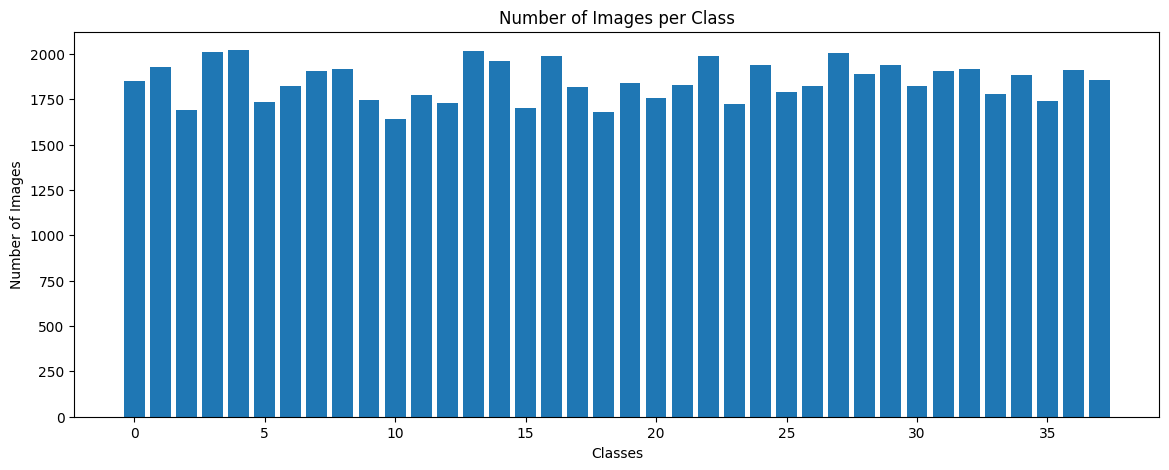

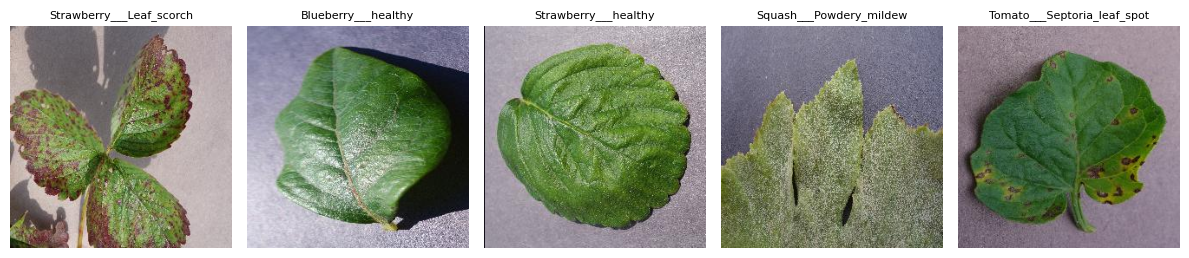

In [6]:
import os
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image

# =====================
# 1) Load Classes 
# =====================
classes = [c for c in os.listdir(train_dir) 
           if os.path.isdir(os.path.join(train_dir, c))]

print("Number of Classes:", len(classes))
print("Sample Classes:", classes[:10])


# =====================
# 2) Count Images per Class
# =====================
class_counts = {}

for c in classes:
    class_path = os.path.join(train_dir, c)
    class_counts[c] = len(os.listdir(class_path))


print("\nSample Class Counts:")
for k in list(class_counts.keys())[:5]:
    print(k, "→", class_counts[k])


# =====================
# 3) Plot Distribution
# =====================
plt.figure(figsize=(14,5))
plt.bar(range(len(classes)), list(class_counts.values()))
plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()


# =====================
# 4) Show Sample Images
# =====================
plt.figure(figsize=(12,6))

for i in range(5):
    class_name = random.choice(classes)
    class_path = os.path.join(train_dir, class_name)
    
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

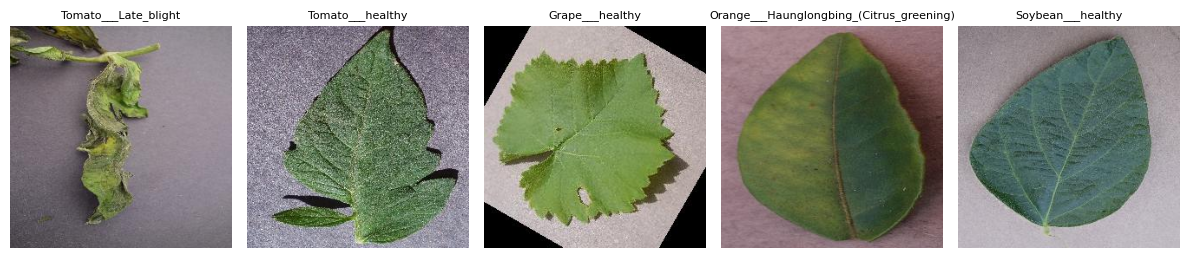

In [7]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing import image
import os

classes = os.listdir(train_dir)

plt.figure(figsize=(12,5))

for i in range(5):
    
    class_name = classes[i]
    
    class_path = os.path.join(train_dir, class_name)
    
    img_name = random.choice(os.listdir(class_path)) 
    
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

In [26]:
def extract_features(folder, max_per_class=100):  # per class, not total
    X = []
    y = []

    for label in os.listdir(folder):
        class_path = os.path.join(folder, label)

        if not os.path.isdir(class_path):
            continue

        count = 0  # reset per class
        for img_name in os.listdir(class_path):

            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)

            try:
                img = image.load_img(img_path, target_size=(224,224))
                img = image.img_to_array(img)
                img = np.expand_dims(img, axis=0)
                img = preprocess_input(img)

                feat = model.predict(img, verbose=0)

                X.append(feat.flatten())
                y.append(label)
                count += 1

            except:
                continue

    return np.array(X), np.array(y)

In [27]:
X_train, y_train = extract_features(train_dir, max_per_class=100)
X_valid, y_valid = extract_features(valid_dir, max_per_class=30)

In [28]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)

In [29]:
import pandas as pd

df_train = pd.DataFrame(X_train_pca)

In [30]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       3800 non-null   float32
 1   1       3800 non-null   float32
 2   2       3800 non-null   float32
 3   3       3800 non-null   float32
 4   4       3800 non-null   float32
 5   5       3800 non-null   float32
 6   6       3800 non-null   float32
 7   7       3800 non-null   float32
 8   8       3800 non-null   float32
 9   9       3800 non-null   float32
 10  10      3800 non-null   float32
 11  11      3800 non-null   float32
 12  12      3800 non-null   float32
 13  13      3800 non-null   float32
 14  14      3800 non-null   float32
 15  15      3800 non-null   float32
 16  16      3800 non-null   float32
 17  17      3800 non-null   float32
 18  18      3800 non-null   float32
 19  19      3800 non-null   float32
 20  20      3800 non-null   float32
 21  21      3800 non-null   float32
 22 

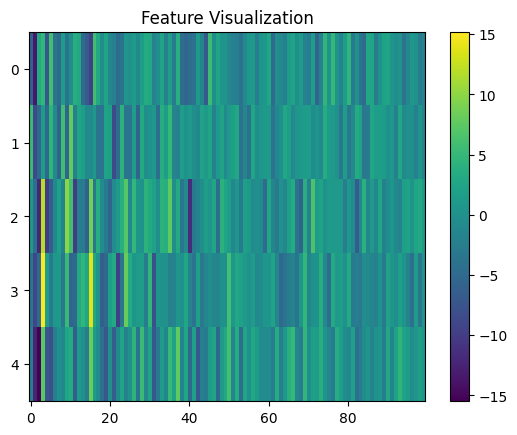

In [31]:
plt.imshow(X_train_pca[:5], aspect='auto')
plt.colorbar()
plt.title("Feature Visualization")
plt.show()

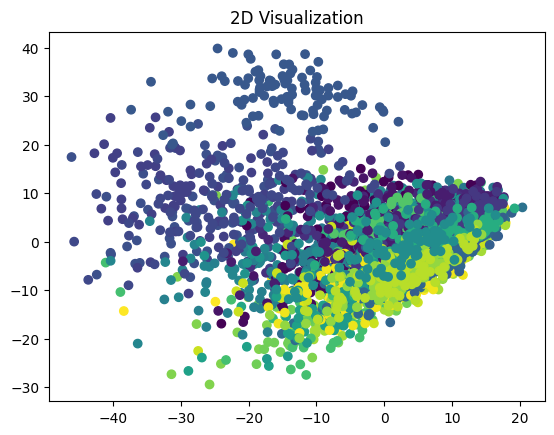

In [32]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_train_scaled)

plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train_enc)
plt.title("2D Visualization")
plt.show()

In [13]:
# ============================================================
#  EfficientNetV2B0 
# ============================================================

import os, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint




In [14]:
# ============================================================
# 1. CONFIG
# ============================================================

IMG_SIZE = 224
BATCH = 64
SEED = 42

# ============================================================
# 2. LOAD DATA
# ============================================================
class_names = sorted([
    c for c in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, c))
])

NUM_CLASSES = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

paths, labels = [], []

for cls in class_names:
    folder = os.path.join(train_dir, cls)
    for img in os.listdir(folder):
        paths.append(os.path.join(folder, img))
        labels.append(class_to_idx[cls])

paths = np.array(paths)
labels = np.array(labels)

print("Total images:", len(paths))
print("Classes:", NUM_CLASSES)


Total images: 70295
Classes: 38


In [16]:
# ============================================================
# 3. STRATIFIED SPLIT (70 / 15 / 15)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(len(X_train), len(X_val), len(X_test))

# ============================================================
# 4. DATA PIPELINE + AUGMENTATION
# ============================================================
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, tf.one_hot(label, NUM_CLASSES)

def load_train(path, label):
    img, label = load_image(path, label)
    img = aug(img, training=True)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(2000).map(load_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)



49206 10544 10545


In [ ]:
# ============================================================
# 5. MODEL
# ============================================================
MODEL_PATH = "/kaggle/working/best_model.keras"

if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model = tf.keras.models.load_model(MODEL_PATH)

else:
    base = EfficientNetV2B0(include_top=False, weights="imagenet")
    base.trainable = False

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)

# ============================================================
# 6. LOSS + OPTIMIZER (IMPORTANT FOR PAPER)
# ============================================================

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

steps_per_epoch = len(X_train) // BATCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 20
)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

In [ ]:
# ============================================================
# 7. TRAIN PHASE 1
# ============================================================



callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

In [ ]:
# ============================================================
# 8. FINE TUNING
# ============================================================
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

In [20]:
# ============================================================
# 9. EVALUATION FUNCTION
# ============================================================
def evaluate(ds):
    y_true = []
    y_pred = []

    for x, y in ds:
        preds = model.predict(x, verbose=0)

        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    print("\nAccuracy:", acc)
    print("F1 Macro:", f1_macro)
    print("F1 Weighted:", f1_weighted)
    print("Precision:", precision)
    print("Recall:", recall)

    return y_true, y_pred


Accuracy: 0.9888088012139605
F1 Macro: 0.9886500054499892
F1 Weighted: 0.9887884294894068
Precision: 0.9892029260643371
Recall: 0.9885187731602822

Accuracy: 0.9895685158843054
F1 Macro: 0.9894072735041687
F1 Weighted: 0.9895643659883361
Precision: 0.989798722791167
Recall: 0.9893002522198763

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.99      0.99       303
                                 Apple___Black_rot       1.00      1.00      1.00       298
                          Apple___Cedar_apple_rust       1.00      0.99      1.00       264
                                   Apple___healthy       0.99      1.00      0.99       301
                               Blueberry___healthy       1.00      1.00      1.00       272
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       252
                 Cherry_(including_

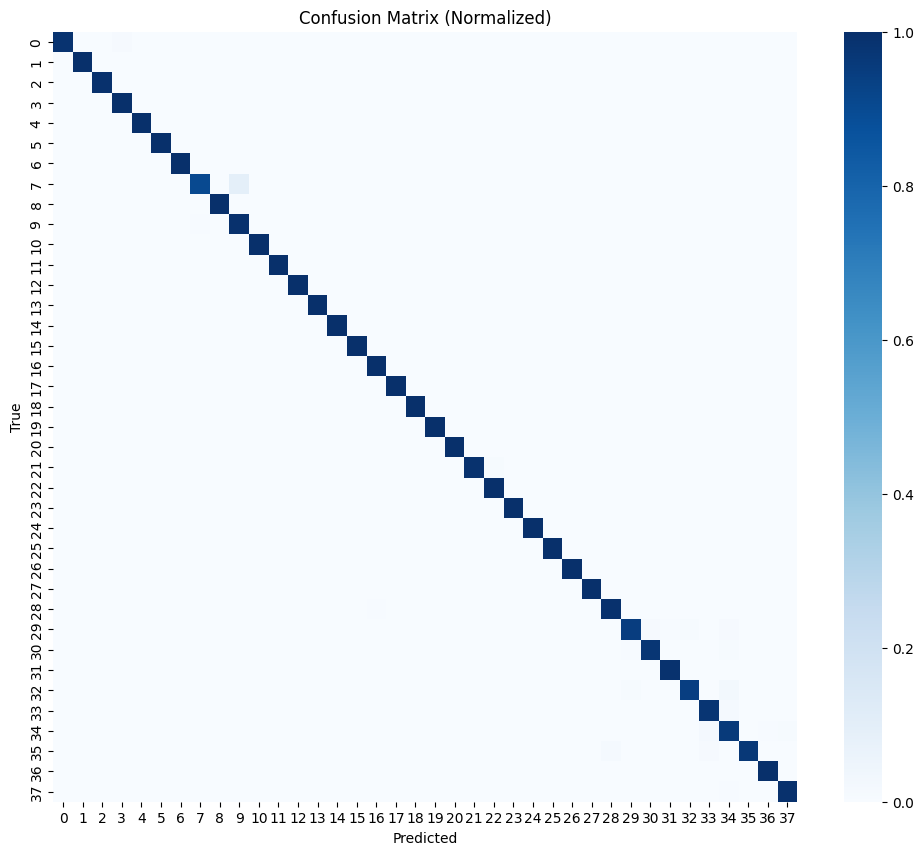

Apple___Apple_scab : 0.9868
Apple___Black_rot : 1.0
Apple___Cedar_apple_rust : 0.9924
Apple___healthy : 1.0
Blueberry___healthy : 1.0
Cherry_(including_sour)___Powdery_mildew : 1.0
Cherry_(including_sour)___healthy : 0.9964
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 0.9024
Corn_(maize)___Common_rust_ : 1.0
Corn_(maize)___Northern_Leaf_Blight : 0.993
Corn_(maize)___healthy : 1.0
Grape___Black_rot : 1.0
Grape___Esca_(Black_Measles) : 1.0
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 1.0
Grape___healthy : 1.0
Orange___Haunglongbing_(Citrus_greening) : 1.0
Peach___Bacterial_spot : 0.9964
Peach___healthy : 1.0
Pepper,_bell___Bacterial_spot : 0.9965
Pepper,_bell___healthy : 0.9966
Potato___Early_blight : 1.0
Potato___Late_blight : 0.9897
Potato___healthy : 1.0
Raspberry___healthy : 1.0
Soybean___healthy : 1.0
Squash___Powdery_mildew : 1.0
Strawberry___Leaf_scorch : 1.0
Strawberry___healthy : 1.0
Tomato___Bacterial_spot : 0.9961
Tomato___Early_blight : 0.9479
Tomato___Late_blight : 0

In [22]:
# ============================================================
# 10. VALIDATION + TEST
# ============================================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


val_true, val_pred   = evaluate(val_ds)
test_true, test_pred = evaluate(test_ds)

print("\nClassification Report:\n")
print(classification_report(test_true, test_pred, target_names=class_names))

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(test_true, test_pred)
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()

# ============================================================
# 12. PER CLASS ACCURACY
# ============================================================
cm_raw = confusion_matrix(test_true, test_pred)
per_class = cm_raw.diagonal() / cm_raw.sum(axis=1)

for i, acc in enumerate(per_class):
    print(class_names[i], ":", round(acc, 4))

In [ ]:
# ============================================================
# 13. OVERFITTING GAP
# ============================================================
train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc   = history1.history["val_accuracy"] + history2.history["val_accuracy"]

gap = abs(train_acc[-1] - val_acc[-1])
print("Overfitting Gap:", gap)
# ============================================================
# 14. SAVE
# ============================================================
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

model.save("/kaggle/working/final_model.keras")



Overfitting Gap: 2.6941299438476562e-05

In [17]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json
import os

DATASET_PATH = "/kaggle/input/datasets/ayamahmoudalhareidi/dmprojectds"


model = load_model(f"{DATASET_PATH}/final_model.keras")


with open(f"{DATASET_PATH}/class_names.json", "r") as f:
    class_names = json.load(f)


if isinstance(class_names, dict):
    class_names = list(class_names.values())

print(" Model Loaded")
print(" Number of Classes:", len(class_names))



 Model Loaded
 Number of Classes: 38


Running prediction...


2026-05-18 19:14:30.621820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 19:14:30.757446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted Class: Apple___Apple_scab
Confidence: 0.8775217533111572


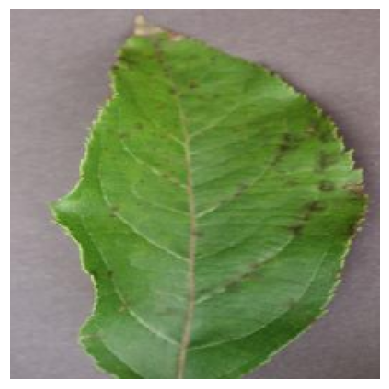

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class: Apple___Cedar_apple_rust
Confidence: 0.9516220092773438


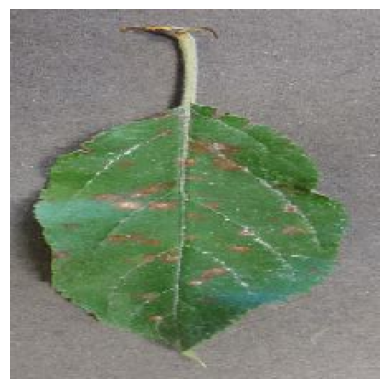

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Class: Tomato___Target_Spot
Confidence: 0.830431342124939


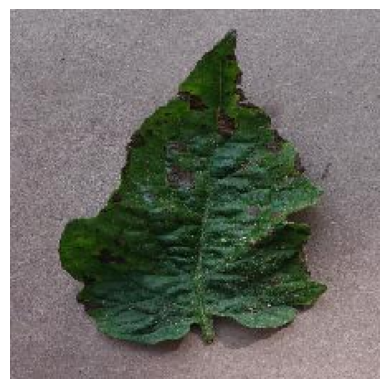

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence: 0.8975293040275574


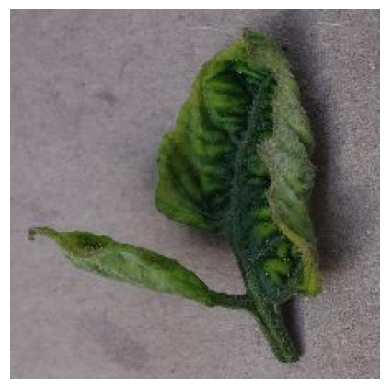

Running prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Class: Potato___healthy
Confidence: 0.721507728099823


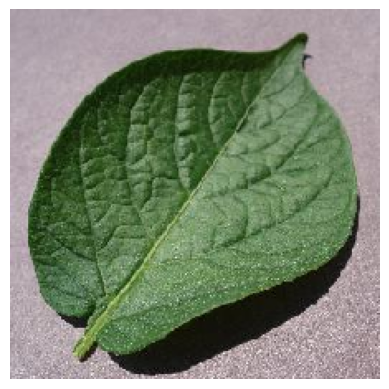

In [23]:

img_path6="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/AppleScab1.JPG"
img_path7="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/AppleCedarRust2.JPG"
img_path8="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoEarlyBlight3.JPG"
img_path9="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus3.JPG"
img_path0="/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy2.JPG"

def predict_image(img_path):
    print("Running prediction...")

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)

    pred = model.predict(img_array)
    class_index = np.argmax(pred)

    print("Predicted Class:", class_names[class_index])
    print("Confidence:", float(np.max(pred)))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

predict_image(img_path6)
predict_image(img_path7)
predict_image(img_path8)
predict_image(img_path9)
predict_image(img_path0)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lr  = LogisticRegression(max_iter=3000, solver='saga', C=10, n_jobs=-1)
lr.fit(X_train_pca, y_train_enc)

svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True)
svm.fit(X_train_pca, y_train_enc)

rf  = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train_enc)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train_enc)

print("Done ")

Done 


In [34]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('rf', rf)],
    voting='soft'
)
ensemble.fit(X_train_pca, y_train_enc)
print("Ensemble Done ")

Ensemble Done 


In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf,
    "KNN": knn,
    "Ensemble": ensemble
}

for name, m in models.items():
    pred = m.predict(X_valid_pca)
    print(f"\n{name}:")
    print(f"  Accuracy  : {round(accuracy_score(y_valid_enc, pred), 4)}")
    print(f"  F1        : {round(f1_score(y_valid_enc, pred, average='weighted'), 4)}")
    print(f"  Precision : {round(precision_score(y_valid_enc, pred, average='weighted'), 4)}")
    print(f"  Recall    : {round(recall_score(y_valid_enc, pred, average='weighted'), 4)}")


Logistic Regression:
  Accuracy  : 0.9202
  F1        : 0.9204
  Precision : 0.9226
  Recall    : 0.9202

SVM:
  Accuracy  : 0.9298
  F1        : 0.9298
  Precision : 0.9323
  Recall    : 0.9298

Random Forest:
  Accuracy  : 0.8746
  F1        : 0.8737
  Precision : 0.8798
  Recall    : 0.8746

KNN:
  Accuracy  : 0.8535
  F1        : 0.8509
  Precision : 0.8594
  Recall    : 0.8535

Ensemble:
  Accuracy  : 0.9237
  F1        : 0.9239
  Precision : 0.9264
  Recall    : 0.9237


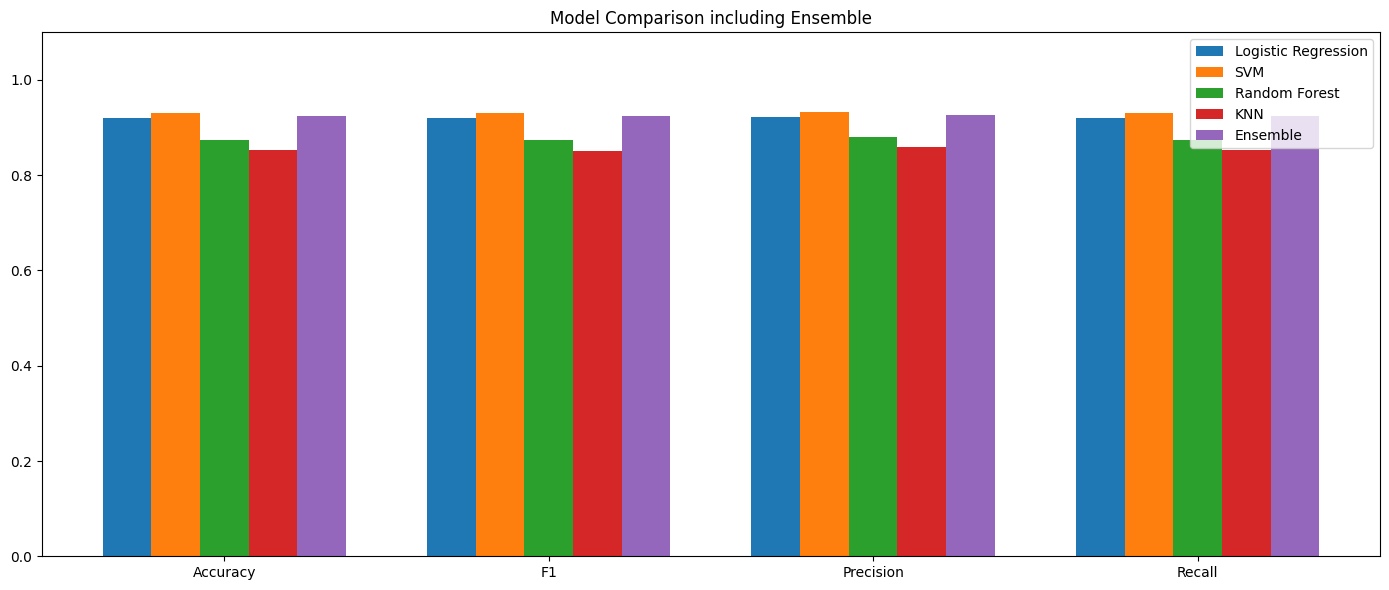

In [36]:
import matplotlib.pyplot as plt
import numpy as np

metric_names = ["Accuracy", "F1", "Precision", "Recall"]
metrics_data = {}

for name, m in models.items():
    pred = m.predict(X_valid_pca)
    metrics_data[name] = [
        accuracy_score(y_valid_enc, pred),
        f1_score(y_valid_enc, pred, average="weighted"),
        precision_score(y_valid_enc, pred, average="weighted"),
        recall_score(y_valid_enc, pred, average="weighted")
    ]

x = np.arange(len(metric_names))
width = 0.15

plt.figure(figsize=(14, 6))
for i, name in enumerate(models.keys()):
    plt.bar(x + i * width, metrics_data[name], width=width, label=name)

plt.xticks(x + width * 2, metric_names)
plt.ylim(0, 1.1)
plt.title("Model Comparison including Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

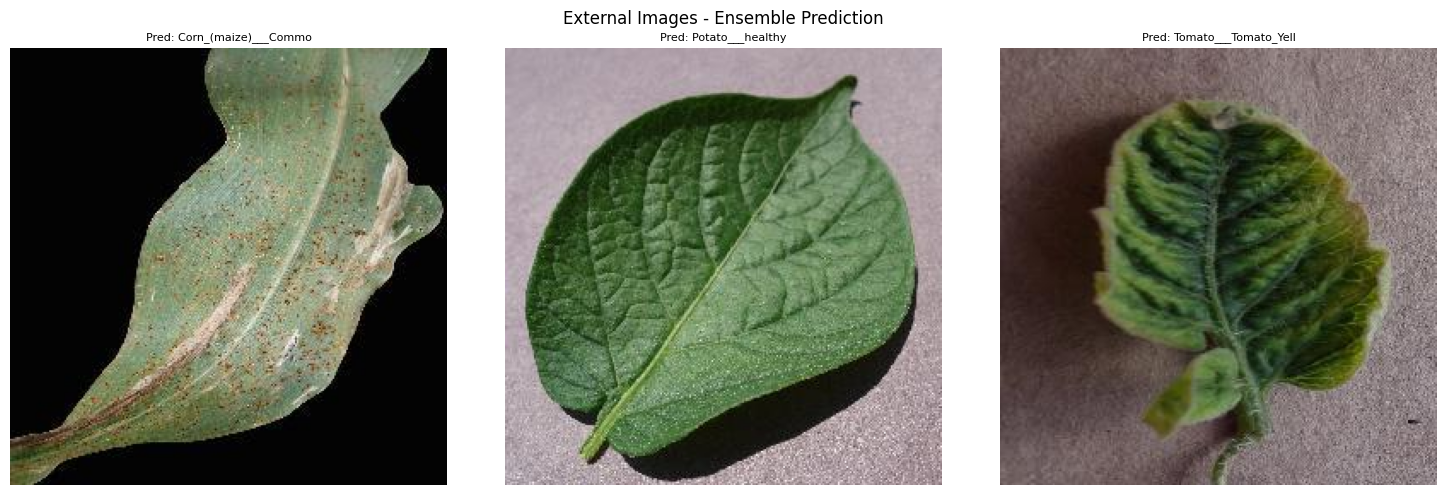

In [37]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess


model_resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')

external_images = [
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/CornCommonRust1.JPG",
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy2.JPG",
    "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/TomatoYellowCurlVirus2.JPG",
]

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(external_images):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)  

    feat = model_resnet.predict(img_array, verbose=0).flatten() 
    feat_scaled = scaler.transform([feat])
    feat_pca = pca.transform(feat_scaled)

    pred_label = ensemble.predict(feat_pca)[0]
    pred_name  = le.inverse_transform([pred_label])[0]

    plt.subplot(1, len(external_images), i + 1)
    plt.imshow(image.load_img(img_path))
    plt.title(f"Pred: {pred_name[:20]}", fontsize=8)
    plt.axis("off")

plt.suptitle("External Images - Ensemble Prediction", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open("/kaggle/working/ensemble.pkl", "wb") as f:

    pickle.dump({
        "ensemble": ensemble,
        "scaler": scaler,
        "pca": pca,
        "le": le
    }, f)

print("Ensemble saved successfully ")

In [38]:
# ═══════════════════════════════════════════════════
#   PlantGuard AI — LAUNCH (Run this cell only)
# ═══════════════════════════════════════════════════

import shutil, os, threading, time, subprocess, re

# ── 1. Copy all files to working directory ──────────
files_to_copy = {
    "/kaggle/input/datasets/ayamahmoudalhareidi/guiapp2/plant_app.py":   "/kaggle/working/plant_app.py",
    "/kaggle/input/datasets/ayamahmoudalhareidi/dmprojectds/final_model.keras": "/kaggle/working/final_model.keras",
    "/kaggle/input/datasets/ayamahmoudalhareidi/dmprojectds/class_names.json":  "/kaggle/working/class_names.json",
    "/kaggle/input/datasets/ayamahmoudalhareidi/ml-models/ensemble.pkl":         "/kaggle/working/ensemble.pkl",
}

for src, dst in files_to_copy.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"OK: {os.path.basename(dst)}")
    else:
        print(f"NOT FOUND: {src}")

# ── 2. Install streamlit ────────────────────────────
os.system("pip install streamlit -q")

# ── 3. Kill any old processes ───────────────────────
os.system("pkill -f streamlit 2>/dev/null")
os.system("pkill -f cloudflared 2>/dev/null")
time.sleep(2)

# ── 4. Start Streamlit ──────────────────────────────
threading.Thread(
    target=lambda: os.system(
        "streamlit run /kaggle/working/plant_app.py "
        "--server.port 8501 --server.headless true "
        "> /tmp/st.log 2>&1"
    ),
    daemon=True
).start()

time.sleep(8)

# ── 5. Check Streamlit started OK ──────────────────
log = open("/tmp/st.log").read()
if "Uvicorn server started" in log:
    print("Streamlit is running OK")
else:
    print("Streamlit log:")
    print(log)
# ── 6. Start Cloudflare tunnel ──────────────────────
os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared")
os.system("chmod +x /usr/local/bin/cloudflared")

proc = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("Getting public URL...")

for line in proc.stdout:
    line = line.decode().strip()
    if "trycloudflare.com" in line:
        url = re.search(r'https://[^\s]+trycloudflare\.com', line)
        if url:
            print("\n" + "="*50)
            print("  PlantGuard AI is LIVE!")
            print(f"  Open: {url.group()}")
            print("="*50)
            break

OK: plant_app.py
OK: final_model.keras
OK: class_names.json
OK: ensemble.pkl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 18.8 MB/s eta 0:00:00
Streamlit is running OK
Getting public URL...

  PlantGuard AI is LIVE!
  Open: https://lie-threats-included-flavor.trycloudflare.com
